In [33]:
import numpy as np
import matplotlib.pyplot as plt

In [44]:
alpha = 0.01
beta = 1
n = 3000000

x_values= np.zeros(n)
x_values[0] = 5

for i in range(1, n):
    noise = np.random.randn()
    x_values[i] = x_values[i-1] - alpha*(x_values[i-1]**3 - x_values[i-1]) + np.sqrt(2*alpha/beta)*noise
  

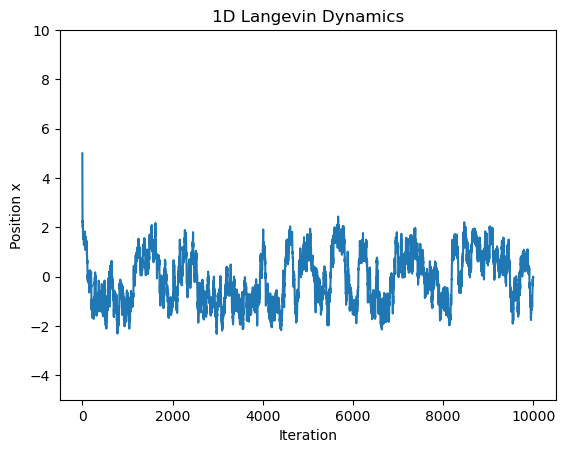

In [45]:
plt.plot(x_values[:10000])
plt.xlabel("Iteration")
plt.ylabel("Position x")
plt.ylim(-5,10)
plt.title("1D Langevin Dynamics")
plt.show()



Results from Trajectory:
Starting from initial value of 5, the position x appears to be fluctuating between -2 and +2 (which suggest the mean is stable after a few thousand iterations)

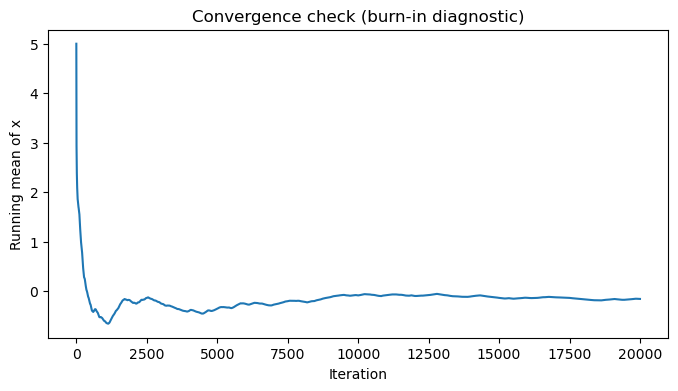

In [46]:

running_mean = np.cumsum(x_values) / np.arange(1, len(x_values)+1)

plt.figure(figsize=(8,4))
plt.plot(running_mean[:20000])  # zoom first part
plt.xlabel("Iteration")
plt.ylabel("Running mean of x")
plt.title("Convergence check (burn-in diagnostic)")
plt.show()

Running mean results:
It shows that after approximately 10000 iterations the running mean reaches a plateau which justifies the burn-in value using to plot the histogram

Text(0.5, 0, 'x')

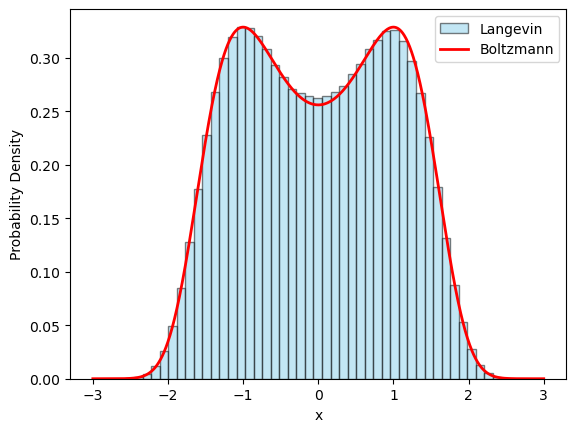

In [47]:
x_eq = x_values[10000:]
x = np.linspace(-3,3,1000)

p = np.exp(beta*(-(1/4)*x**4+(1/2)*x**2))
pdf = p/np.trapezoid(p,x)

fig, ax = plt.subplots()

ax.hist(x_eq, bins=50, density=True, alpha=0.5,color='skyblue', edgecolor='black',label='Langevin')

ax.plot(x, pdf, color='red', linewidth=2, label='Boltzmann')
ax.legend()
ax.set_ylabel("Probability Density")
ax.set_xlabel("x")

In [48]:
def flyvbjerg_petersen(data):

    data = np.asarray(data, dtype=float).copy()

    block_sizes = []
    standard_errors = []

    block_size = 1

    while len(data) >= 16:

        n = len(data)

        variance = np.var(data, ddof=1)

        error = np.sqrt(variance / n)

        block_sizes.append(block_size)
        standard_errors.append(error)

        # If odd number of samples, discard the last one
        if n % 2 == 1:
            data = data[:-1]

        # Average neighboring pairs
        data = 0.5 * (data[0::2] + data[1::2])

        block_size *= 2

    return np.array(block_sizes), np.array(standard_errors)

In [49]:
block_sizes, errors = flyvbjerg_petersen(x_eq)
print(block_sizes)
print(errors)

[     1      2      4      8     16     32     64    128    256    512
   1024   2048   4096   8192  16384  32768  65536 131072]
[0.00058809 0.00082965 0.00116906 0.00164261 0.00229477 0.00317105
 0.00429757 0.00562525 0.00696862 0.00802468 0.0085209  0.00877264
 0.00858083 0.00873916 0.00835067 0.00820549 0.00741488 0.00725718]


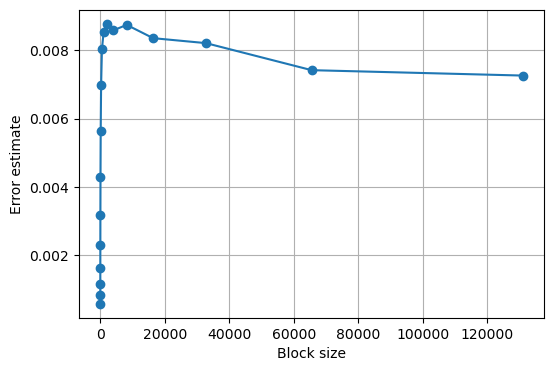

In [ ]:
plt.figure(figsize=(6,4))

plt.plot(block_sizes, errors, 'o-')


plt.xlabel("Block size")
plt.ylabel("Error estimate")

plt.grid(True)

plt.show()

This is an effort to check how the error estimate varies with the block sizes. It turns out the number of independent samples are far less compared to the 3M steps. 

In [51]:
hist, bin_edges = np.histogram(
    x_eq,
    bins=50,
    density=True
)

In [52]:
hist_errors = []

for i in range(len(hist)):

    indicator = (
        (x_eq >= bin_edges[i]) &
        (x_eq < bin_edges[i+1])
    ).astype(float)

    _, errors = flyvbjerg_petersen(indicator)

    idx = np.argmax(errors)

    plateau = np.mean(
        errors[max(0, idx-1):min(len(errors), idx+2)]
    )

    hist_errors.append(plateau)

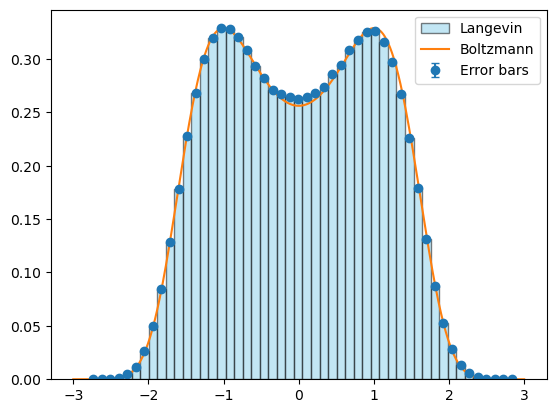

In [54]:
bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])

plt.hist(x_eq, bins=bin_edges, density=True, alpha=0.5,color='skyblue', edgecolor='black',label='Langevin')


plt.errorbar(
    bin_centers,
    hist,
    yerr=hist_errors,
    fmt='o',
    capsize=3,
    label='Error bars'
)

plt.plot(x, pdf, label='Boltzmann')
plt.legend()
plt.show()

This plot includes the error bars of each bin. The error bars have been determined considering the dependecies of the x-values upon each other. Hence, the Flyvbjerg-Peterson method was used